# Phase 3 — Deep Learning Fundamentals

**Course:** ML, Deep Learning & Computer Vision  
**Classes:** 12–18 (7 classes × 2 hours)  
**Prerequisites:** Phases 1–2 (Python, NumPy, Pandas, classical ML)  

---

This notebook takes you from a single neuron to a trained deep network. Every concept is paired with:
- **Math** — the equation behind it
- **Intuition** — what it means in plain language
- **Code** — a working NumPy implementation
- **Visualisation** — a plot that makes it click

By the end, you'll understand every line of a PyTorch training loop — not just *how* to write it, but *why* each part exists.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['figure.figsize'] = (10, 4)
matplotlib.rcParams['figure.dpi'] = 100
np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)

---
# Chapter 1 — The Neuron

## 1.1 What is a neuron?

A neuron is the simplest unit of a neural network. It takes inputs, multiplies each by a **weight**, adds a **bias**, and passes the result through an **activation function**.

$$z = w_1 x_1 + w_2 x_2 + \ldots + w_n x_n + b = \mathbf{w}^T \mathbf{x} + b$$
$$a = \sigma(z)$$

where:
- $\mathbf{x}$ = input features (e.g., pixel values, measurements)
- $\mathbf{w}$ = weights (learnable parameters — how much each input matters)
- $b$ = bias (learnable — shifts the decision boundary)
- $\sigma$ = activation function (introduces non-linearity)
- $a$ = output (the neuron's "activation")

**Intuition:** A neuron is a linear classifier that draws a line (hyperplane) through the input space, then squashes the result through a non-linear function.

In [3]:
def neuron(x, w, b):
    """A single neuron: linear combination + sigmoid activation."""
    z = np.dot(w, x) + b     # linear part
    a = 1 / (1 + np.exp(-z))  # sigmoid activation
    return a, z

# Example: 3 inputs, 1 neuron
x = np.array([0.5, 0.3, 0.2])   # inputs (e.g., 3 features)
w = np.array([0.4, -0.2, 0.6])  # weights (learned)
b = 0.1                          # bias (learned)

a, z = neuron(x, w, b)
print(f"Linear combination z = w·x + b = {z:.4f}")
print(f"After sigmoid:     a = σ(z)    = {a:.4f}")
print(f"\nInterpretation: This neuron outputs {a:.1%} probability")
print(f"  Positive weights (w1={w[0]}, w3={w[2]}) → these inputs push output UP")
print(f"  Negative weight  (w2={w[1]}) → this input pushes output DOWN")

Linear combination z = w·x + b = 0.3600
After sigmoid:     a = σ(z)    = 0.5890

Interpretation: This neuron outputs 58.9% probability
  Positive weights (w1=0.4, w3=0.6) → these inputs push output UP
  Negative weight  (w2=-0.2) → this input pushes output DOWN


## 1.2 Activation functions

**Why do we need them?** Without activation functions, stacking layers is pointless — multiple linear layers collapse into a single linear transformation. Non-linearity is what gives neural networks their power.

| Function | Formula | Range | Pros | Cons |
|----------|---------|-------|------|------|
| **Sigmoid** | $\frac{1}{1+e^{-z}}$ | (0, 1) | Smooth, probabilistic | Vanishing gradient, not zero-centred |
| **Tanh** | $\frac{e^z - e^{-z}}{e^z + e^{-z}}$ | (-1, 1) | Zero-centred | Still vanishing gradient |
| **ReLU** | $\max(0, z)$ | [0, ∞) | Fast, no vanishing gradient | Dead neurons (if z < 0 always) |
| **Leaky ReLU** | $z$ if $z>0$, else $0.01z$ | (-∞, ∞) | Fixes dead neurons | Slightly more complex |
| **GELU** | $z \cdot \Phi(z)$ | (-∞, ∞) | Smooth ReLU, used in transformers | Expensive to compute |

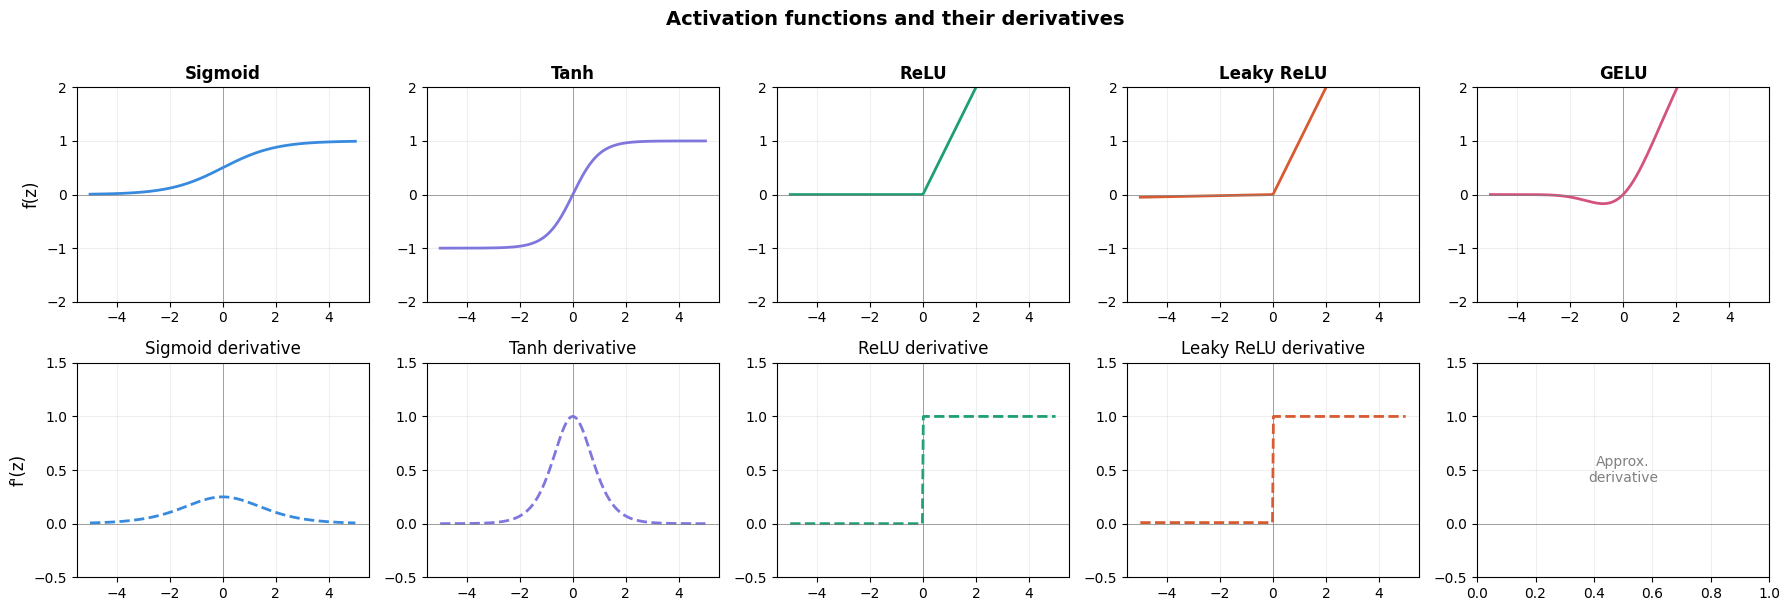

Key insight: sigmoid/tanh derivatives → 0 for large |z| (vanishing gradient problem)
ReLU derivative is either 0 or 1 — gradients flow perfectly when active.


In [4]:
def sigmoid(z):  return 1 / (1 + np.exp(-z))
def tanh(z):     return np.tanh(z)
def relu(z):     return np.maximum(0, z)
def leaky_relu(z, alpha=0.01): return np.where(z > 0, z, alpha * z)
def gelu(z):     return z * 0.5 * (1 + np.tanh(np.sqrt(2/np.pi) * (z + 0.044715 * z**3)))

# Also compute derivatives (needed for backprop)
def sigmoid_deriv(z):    s = sigmoid(z); return s * (1 - s)
def tanh_deriv(z):       return 1 - np.tanh(z)**2
def relu_deriv(z):       return (z > 0).astype(float)
def leaky_relu_deriv(z): return np.where(z > 0, 1, 0.01)

z = np.linspace(-5, 5, 300)
activations = [
    ("Sigmoid", sigmoid, sigmoid_deriv, "#378ADD"),
    ("Tanh", tanh, tanh_deriv, "#7F77DD"),
    ("ReLU", relu, relu_deriv, "#1D9E75"),
    ("Leaky ReLU", leaky_relu, leaky_relu_deriv, "#D85A30"),
    ("GELU", gelu, None, "#D4537E"),
]

fig, axes = plt.subplots(2, 5, figsize=(18, 6))
for i, (name, fn, deriv, color) in enumerate(activations):
    axes[0, i].plot(z, fn(z), color=color, linewidth=2)
    axes[0, i].axhline(0, color='gray', linewidth=0.5)
    axes[0, i].axvline(0, color='gray', linewidth=0.5)
    axes[0, i].set_title(name, fontweight='bold')
    axes[0, i].set_ylim(-2, 2)
    axes[0, i].grid(True, alpha=0.2)

    if deriv:
        axes[1, i].plot(z, deriv(z), color=color, linewidth=2, linestyle='--')
        axes[1, i].set_title(f"{name} derivative")
    else:
        axes[1, i].text(0.5, 0.5, 'Approx.\nderivative', ha='center', va='center', transform=axes[1,i].transAxes, color='gray')
    axes[1, i].axhline(0, color='gray', linewidth=0.5)
    axes[1, i].axvline(0, color='gray', linewidth=0.5)
    axes[1, i].set_ylim(-0.5, 1.5)
    axes[1, i].grid(True, alpha=0.2)

axes[0, 0].set_ylabel('f(z)', fontsize=12)
axes[1, 0].set_ylabel("f'(z)", fontsize=12)
plt.suptitle("Activation functions and their derivatives", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Key insight: sigmoid/tanh derivatives → 0 for large |z| (vanishing gradient problem)")
print("ReLU derivative is either 0 or 1 — gradients flow perfectly when active.")

## 1.3 Why non-linearity matters — a visual proof

Without activation functions, a neural network can only draw straight lines. Let's prove it.

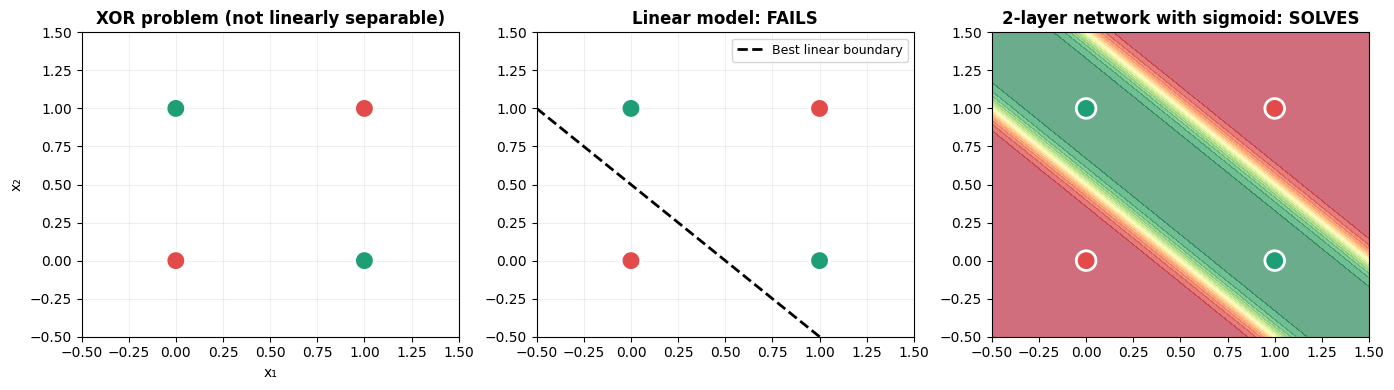

The hidden layer transforms the input space so that XOR becomes linearly separable.
This is the fundamental insight of deep learning: learn the representation.


In [5]:
# XOR problem: not linearly separable
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])  # XOR: same inputs → 0, different → 1

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Plot XOR data
colors = ['#E24B4A' if y == 0 else '#1D9E75' for y in y_xor]
axes[0].scatter(X_xor[:, 0], X_xor[:, 1], c=colors, s=200, edgecolors='white', linewidth=2, zorder=5)
axes[0].set_title('XOR problem (not linearly separable)', fontweight='bold')
axes[0].set_xlabel('x₁'); axes[0].set_ylabel('x₂')
axes[0].set_xlim(-0.5, 1.5); axes[0].set_ylim(-0.5, 1.5)
axes[0].grid(True, alpha=0.2)

# Without activation: linear boundary (FAILS)
# Best linear attempt: w1*x1 + w2*x2 + b = 0
xx = np.linspace(-0.5, 1.5, 100)
axes[1].scatter(X_xor[:, 0], X_xor[:, 1], c=colors, s=200, edgecolors='white', linewidth=2, zorder=5)
axes[1].plot(xx, -xx + 0.5, 'k--', linewidth=2, label='Best linear boundary')
axes[1].set_title('Linear model: FAILS', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_xlim(-0.5, 1.5); axes[1].set_ylim(-0.5, 1.5)
axes[1].grid(True, alpha=0.2)

# With activation: 2-layer network SOLVES it
# Hidden layer transforms the space
W1 = np.array([[20, 20], [20, 20]])   # same direction, different bias
b1 = np.array([-10, -30])
W2 = np.array([1, -1])
b2 = -0.5

xx2, yy2 = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = np.c_[xx2.ravel(), yy2.ravel()]
h = sigmoid(grid @ W1.T + b1)
out = sigmoid(h @ W2 + b2)
out = out.reshape(xx2.shape)

axes[2].contourf(xx2, yy2, out, levels=20, cmap='RdYlGn', alpha=0.6)
axes[2].scatter(X_xor[:, 0], X_xor[:, 1], c=colors, s=200, edgecolors='white', linewidth=2, zorder=5)
axes[2].set_title('2-layer network with sigmoid: SOLVES', fontweight='bold')
axes[2].set_xlim(-0.5, 1.5); axes[2].set_ylim(-0.5, 1.5)

plt.tight_layout()
plt.show()

print("The hidden layer transforms the input space so that XOR becomes linearly separable.")
print("This is the fundamental insight of deep learning: learn the representation.")

---
# Chapter 2 — Feedforward Networks

## 2.1 From one neuron to a layer

A **layer** is just many neurons operating in parallel on the same input:

$$\mathbf{z} = \mathbf{W} \mathbf{x} + \mathbf{b}$$
$$\mathbf{a} = \sigma(\mathbf{z})$$

where $\mathbf{W}$ is a matrix of shape `(n_neurons, n_inputs)` — each row is one neuron's weights.

**Key insight:** A layer is just a matrix multiplication + activation. That's it.

In [7]:
class DenseLayer:
    """A single fully-connected layer, implemented from scratch."""

    def __init__(self, n_inputs, n_neurons, activation='relu'):
        # He initialisation (good for ReLU)
        self.W = np.random.randn(n_neurons, n_inputs) * np.sqrt(2 / n_inputs)
        self.b = np.zeros(n_neurons)
        self.activation = activation

    def forward(self, X):
        """X shape: (batch_size, n_inputs) → output shape: (batch_size, n_neurons)"""
        self.X = X  # save for backprop
        self.z = X @ self.W.T + self.b  # linear

        if self.activation == 'relu':
            self.a = np.maximum(0, self.z)
        elif self.activation == 'sigmoid':
            self.a = 1 / (1 + np.exp(-self.z))
        elif self.activation == 'none':
            self.a = self.z

        return self.a

    def __repr__(self):
        return f"DenseLayer({self.W.shape[1]} → {self.W.shape[0]}, {self.activation})"

# Demo: a layer with 4 inputs and 3 neurons
layer = DenseLayer(4, 3, activation='relu')
print(layer)
print(f"Weight matrix shape: {layer.W.shape}")  # (3, 4)
print(f"Bias shape: {layer.b.shape}")            # (3,)

# Forward pass on a batch of 5 samples
X = np.random.randn(5, 4)  # 5 samples, 4 features
output = layer.forward(X)
print(f"\nInput shape:  {X.shape}")       # (5, 4)
print(f"Output shape: {output.shape}")    # (5, 3)
print(f"Output:\n{output.round(3)}")

DenseLayer(4 → 3, relu)
Weight matrix shape: (3, 4)
Bias shape: (3,)

Input shape:  (5, 4)
Output shape: (5, 3)
Output:
[[0.    0.    0.   ]
 [0.    0.    1.219]
 [0.    0.    0.   ]
 [0.    0.    0.477]
 [1.537 0.481 0.   ]]


## 2.2 Stacking layers → a network

A feedforward neural network is layers stacked sequentially: the output of each layer is the input to the next.

**Architecture:** Input → Hidden Layer 1 → Hidden Layer 2 → ... → Output Layer

The number of hidden layers is the **depth**. The number of neurons per layer is the **width**.

In [8]:
class NeuralNetwork:
    """A simple feedforward network from scratch."""

    def __init__(self, layer_sizes, activations):
        """
        layer_sizes: [input_dim, hidden1, hidden2, ..., output_dim]
        activations: ['relu', 'relu', ..., 'none'] (one per layer after input)
        """
        self.layers = []
        for i in range(len(layer_sizes) - 1):
            self.layers.append(DenseLayer(layer_sizes[i], layer_sizes[i+1], activations[i]))

    def forward(self, X):
        """Pass input through all layers."""
        out = X
        for layer in self.layers:
            out = layer.forward(out)
        return out

    def count_params(self):
        total = 0
        for l in self.layers:
            total += l.W.size + l.b.size
        return total

    def __repr__(self):
        desc = "NeuralNetwork(\n"
        for i, l in enumerate(self.layers):
            desc += f"  Layer {i}: {l}\n"
        desc += f"  Total params: {self.count_params():,}\n)"
        return desc

# Build a network: 784 inputs → 256 → 128 → 10 outputs (MNIST-sized)
net = NeuralNetwork(
    layer_sizes=[784, 256, 128, 10],
    activations=['relu', 'relu', 'none']
)
print(net)

# Forward pass on a fake batch of 32 "images" (flattened 28×28)
fake_images = np.random.randn(32, 784)
logits = net.forward(fake_images)
print(f"\nInput shape:  {fake_images.shape}")  # (32, 784)
print(f"Output shape: {logits.shape}")          # (32, 10)
print(f"First sample output (raw logits): {logits[0].round(2)}")

NeuralNetwork(
  Layer 0: DenseLayer(784 → 256, relu)
  Layer 1: DenseLayer(256 → 128, relu)
  Layer 2: DenseLayer(128 → 10, none)
  Total params: 235,146
)

Input shape:  (32, 784)
Output shape: (32, 10)
First sample output (raw logits): [-0.48 -0.33  0.19 -0.36  0.91  2.51 -0.36  0.26  0.15  0.36]


## 2.3 From logits to probabilities: Softmax

The network outputs raw scores (**logits**). To get probabilities, we apply **softmax**:

$$p_i = \frac{e^{z_i}}{\sum_j e^{z_j}}$$

Properties:
- All outputs are in (0, 1)
- They sum to 1.0 (valid probability distribution)
- The highest logit gets the highest probability (but not winner-take-all)

Logits:        [ 2.   1.   0.1 -1.   3. ]
Probabilities: [0.2333 0.0858 0.0349 0.0116 0.6343]
Sum:          1.000000
Prediction:   class 4 (probability 63.4%)


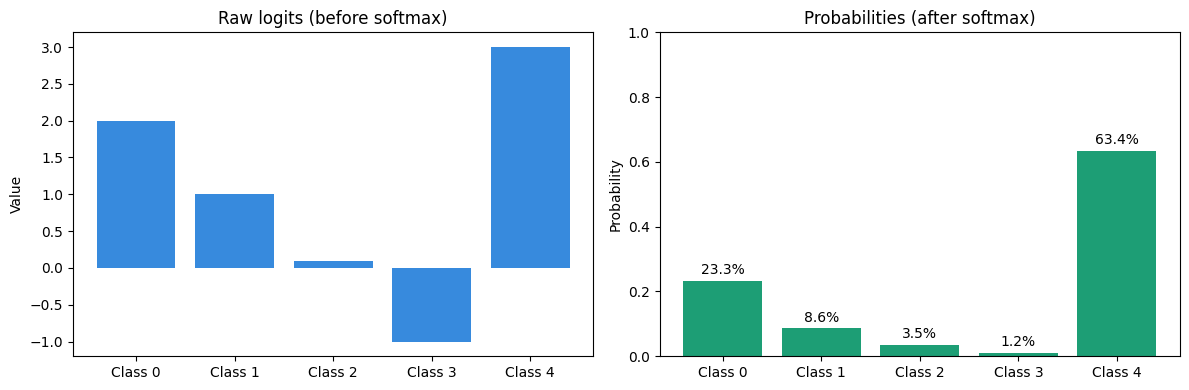

In [9]:
def softmax(z):
    """Numerically stable softmax."""
    e = np.exp(z - z.max(axis=-1, keepdims=True))  # subtract max for stability
    return e / e.sum(axis=-1, keepdims=True)

# Example: convert logits to probabilities
logits_example = np.array([2.0, 1.0, 0.1, -1.0, 3.0])
probs = softmax(logits_example)

print("Logits:       ", logits_example.round(2))
print("Probabilities:", probs.round(4))
print(f"Sum:          {probs.sum():.6f}")
print(f"Prediction:   class {probs.argmax()} (probability {probs.max():.1%})")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
classes = [f"Class {i}" for i in range(5)]
axes[0].bar(classes, logits_example, color='#378ADD')
axes[0].set_title('Raw logits (before softmax)')
axes[0].set_ylabel('Value')

axes[1].bar(classes, probs, color='#1D9E75')
axes[1].set_title('Probabilities (after softmax)')
axes[1].set_ylabel('Probability')
axes[1].set_ylim(0, 1)
for j, p in enumerate(probs):
    axes[1].text(j, p + 0.02, f'{p:.1%}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

---
# Chapter 3 — Loss Functions

The loss function measures **how wrong** the network's predictions are. Training = minimising the loss.

## 3.1 Mean Squared Error (for regression)

$$\mathcal{L}_{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$$

**Intuition:** Average squared distance between predictions and true values. Penalises large errors quadratically.

In [8]:
def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def mse_gradient(y_true, y_pred):
    """Gradient of MSE w.r.t. y_pred"""
    return 2 * (y_pred - y_true) / len(y_true)

# Example
y_true = np.array([3.0, 5.0, 2.5, 7.0])
y_pred = np.array([2.8, 5.2, 2.0, 6.5])

loss = mse_loss(y_true, y_pred)
grad = mse_gradient(y_true, y_pred)

print(f"True values:    {y_true}")
print(f"Predictions:    {y_pred}")
print(f"Errors:         {(y_pred - y_true).round(2)}")
print(f"Squared errors: {((y_true - y_pred)**2).round(4)}")
print(f"MSE Loss:       {loss:.4f}")
print(f"Gradient:       {grad.round(4)}")
print(f"\nThe gradient tells each prediction which direction to move and by how much.")

True values:    [3.  5.  2.5 7. ]
Predictions:    [2.8 5.2 2.  6.5]
Errors:         [-0.2  0.2 -0.5 -0.5]
Squared errors: [0.04 0.04 0.25 0.25]
MSE Loss:       0.1450
Gradient:       [-0.1   0.1  -0.25 -0.25]

The gradient tells each prediction which direction to move and by how much.


## 3.2 Cross-Entropy Loss (for classification)

$$\mathcal{L}_{CE} = -\frac{1}{N} \sum_{i=1}^{N} \log(p_{i, y_i})$$

where $p_{i, y_i}$ is the predicted probability for the **correct** class.

**Intuition:** If the model is confident and right, loss is low. If confident and **wrong**, loss is extremely high. This asymmetry makes learning fast.

In [9]:
def cross_entropy_loss(logits, targets):
    """Cross-entropy from raw logits (numerically stable)."""
    # Stable softmax
    shifted = logits - logits.max(axis=1, keepdims=True)
    log_sum_exp = np.log(np.exp(shifted).sum(axis=1))
    # Gather log-prob of correct class
    correct_logits = logits[np.arange(len(targets)), targets]
    loss_per_sample = -correct_logits + logits.max(axis=1) + log_sum_exp
    return loss_per_sample.mean()

# Example: 4 samples, 3 classes
logits = np.array([
    [2.0, 1.0, 0.1],   # high confidence, correct class 0
    [0.5, 2.5, 0.3],   # high confidence, correct class 1
    [1.0, 1.0, 1.0],   # no confidence (uniform)
    [0.1, 0.2, 2.0],   # high confidence, BUT correct class is 0 → WRONG
])
targets = np.array([0, 1, 2, 0])  # correct classes

probs = softmax(logits)
loss = cross_entropy_loss(logits, targets)

print("Predicted probabilities:")
for i in range(4):
    correct_prob = probs[i, targets[i]]
    status = "✓" if probs[i].argmax() == targets[i] else "✗"
    per_sample_loss = -np.log(correct_prob)
    print(f"  Sample {i}: probs={probs[i].round(3)}, "
          f"P(correct={targets[i]})={correct_prob:.3f}, "
          f"loss={per_sample_loss:.3f} {status}")

print(f"\nMean CE loss: {loss:.4f}")
print(f"\nNotice: sample 3 has HIGH loss because the model is confident but WRONG.")

Predicted probabilities:
  Sample 0: probs=[0.659 0.242 0.099], P(correct=0)=0.659, loss=0.417 ✓
  Sample 1: probs=[0.109 0.802 0.089], P(correct=1)=0.802, loss=0.220 ✓
  Sample 2: probs=[0.333 0.333 0.333], P(correct=2)=0.333, loss=1.099 ✗
  Sample 3: probs=[0.114 0.126 0.761], P(correct=0)=0.114, loss=2.174 ✗

Mean CE loss: 0.9774

Notice: sample 3 has HIGH loss because the model is confident but WRONG.


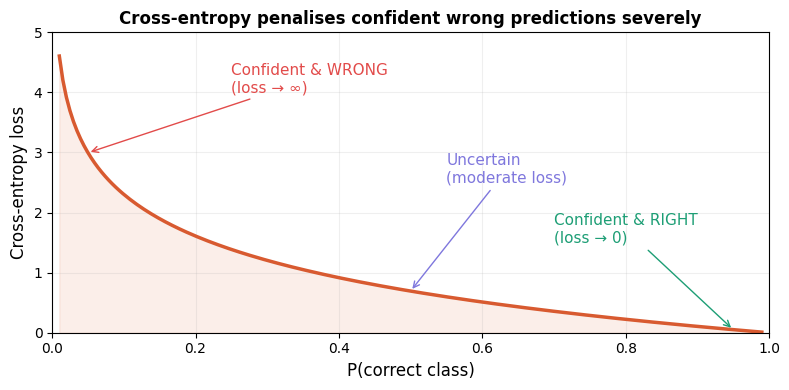

In [10]:
# Visualise: how CE loss responds to confidence
p_correct = np.linspace(0.01, 0.99, 200)
ce = -np.log(p_correct)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(p_correct, ce, color='#D85A30', linewidth=2.5)
ax.fill_between(p_correct, ce, alpha=0.1, color='#D85A30')

# Annotate key points
ax.annotate('Confident & WRONG\n(loss → ∞)', xy=(0.05, -np.log(0.05)),
            xytext=(0.25, 4), fontsize=11, color='#E24B4A',
            arrowprops=dict(arrowstyle='->', color='#E24B4A'))
ax.annotate('Uncertain\n(moderate loss)', xy=(0.5, -np.log(0.5)),
            xytext=(0.55, 2.5), fontsize=11, color='#7F77DD',
            arrowprops=dict(arrowstyle='->', color='#7F77DD'))
ax.annotate('Confident & RIGHT\n(loss → 0)', xy=(0.95, -np.log(0.95)),
            xytext=(0.7, 1.5), fontsize=11, color='#1D9E75',
            arrowprops=dict(arrowstyle='->', color='#1D9E75'))

ax.set_xlabel('P(correct class)', fontsize=12)
ax.set_ylabel('Cross-entropy loss', fontsize=12)
ax.set_title('Cross-entropy penalises confident wrong predictions severely', fontweight='bold')
ax.grid(True, alpha=0.2)
ax.set_xlim(0, 1)
ax.set_ylim(0, 5)
plt.tight_layout()
plt.show()

---
# Chapter 4 — Backpropagation

## 4.1 The chain rule — the engine of learning

Backprop answers: **how much does each weight contribute to the error?**

Using the chain rule of calculus:

$$\frac{\partial \mathcal{L}}{\partial w} = \frac{\partial \mathcal{L}}{\partial a} \cdot \frac{\partial a}{\partial z} \cdot \frac{\partial z}{\partial w}$$

In words: (how much does loss change when output changes) × (how much does output change when pre-activation changes) × (how much does pre-activation change when weight changes)

**Intuition:** We compute the error at the output, then propagate it **backwards** through each layer, computing gradients as we go.

In [10]:
# Let's do backprop BY HAND on a tiny network
# Network: 1 input → 1 hidden (sigmoid) → 1 output (no activation)
# Loss: MSE

# --- Forward pass ---
x = 1.5           # input
y_true = 0.7      # target

w1 = 0.5          # hidden weight
b1 = 0.1          # hidden bias
w2 = 0.3          # output weight
b2 = -0.2         # output bias

# Hidden layer
z1 = w1 * x + b1
a1 = 1 / (1 + np.exp(-z1))  # sigmoid

# Output layer
z2 = w2 * a1 + b2
y_pred = z2  # no activation

# Loss
loss = (y_true - y_pred) ** 2

print("=== FORWARD PASS ===")
print(f"z1 = w1*x + b1 = {w1}*{x} + {b1} = {z1:.4f}")
print(f"a1 = sigmoid(z1) = {a1:.4f}")
print(f"z2 = w2*a1 + b2 = {w2}*{a1:.4f} + {b2} = {z2:.4f}")
print(f"y_pred = {y_pred:.4f}")
print(f"loss = (y_true - y_pred)² = ({y_true} - {y_pred:.4f})² = {loss:.4f}")

=== FORWARD PASS ===
z1 = w1*x + b1 = 0.5*1.5 + 0.1 = 0.8500
a1 = sigmoid(z1) = 0.7006
z2 = w2*a1 + b2 = 0.3*0.7006 + -0.2 = 0.0102
y_pred = 0.0102
loss = (y_true - y_pred)² = (0.7 - 0.0102)² = 0.4759


In [11]:
# --- Backward pass (chain rule) ---
print("=== BACKWARD PASS ===")
print("We compute gradients from output → input, using the chain rule.\n")

# Step 1: dL/dy_pred
dL_dy = 2 * (y_pred - y_true)
print(f"Step 1: dL/dy_pred = 2*(y_pred - y_true) = 2*({y_pred:.4f} - {y_true}) = {dL_dy:.4f}")

# Step 2: dy_pred/dz2 = 1 (no activation)
# So dL/dz2 = dL/dy_pred * 1 = dL_dy
dL_dz2 = dL_dy
print(f"Step 2: dL/dz2 = dL/dy_pred × dy/dz2 = {dL_dy:.4f} × 1 = {dL_dz2:.4f}")

# Step 3: Gradients of output layer weights
dL_dw2 = dL_dz2 * a1  # dz2/dw2 = a1
dL_db2 = dL_dz2 * 1   # dz2/db2 = 1
print(f"Step 3: dL/dw2 = dL/dz2 × a1 = {dL_dz2:.4f} × {a1:.4f} = {dL_dw2:.4f}")
print(f"         dL/db2 = dL/dz2 × 1 = {dL_db2:.4f}")

# Step 4: Propagate to hidden layer
dL_da1 = dL_dz2 * w2  # dz2/da1 = w2
print(f"Step 4: dL/da1 = dL/dz2 × w2 = {dL_dz2:.4f} × {w2} = {dL_da1:.4f}")

# Step 5: Through sigmoid derivative
sig_deriv = a1 * (1 - a1)  # sigmoid'(z) = sigmoid(z) * (1 - sigmoid(z))
dL_dz1 = dL_da1 * sig_deriv
print(f"Step 5: sigmoid'(z1) = a1*(1-a1) = {a1:.4f}*{1-a1:.4f} = {sig_deriv:.4f}")
print(f"         dL/dz1 = dL/da1 × sigmoid'(z1) = {dL_da1:.4f} × {sig_deriv:.4f} = {dL_dz1:.4f}")

# Step 6: Gradients of hidden layer weights
dL_dw1 = dL_dz1 * x
dL_db1 = dL_dz1 * 1
print(f"Step 6: dL/dw1 = dL/dz1 × x = {dL_dz1:.4f} × {x} = {dL_dw1:.4f}")
print(f"         dL/db1 = dL/dz1 × 1 = {dL_db1:.4f}")

print(f"\n=== SUMMARY ===")
print(f"Gradients: dw2={dL_dw2:.4f}, db2={dL_db2:.4f}, dw1={dL_dw1:.4f}, db1={dL_db1:.4f}")
print(f"These tell us: to reduce the loss, nudge each weight in the OPPOSITE direction of its gradient.")

=== BACKWARD PASS ===
We compute gradients from output → input, using the chain rule.

Step 1: dL/dy_pred = 2*(y_pred - y_true) = 2*(0.0102 - 0.7) = -1.3797
Step 2: dL/dz2 = dL/dy_pred × dy/dz2 = -1.3797 × 1 = -1.3797
Step 3: dL/dw2 = dL/dz2 × a1 = -1.3797 × 0.7006 = -0.9665
         dL/db2 = dL/dz2 × 1 = -1.3797
Step 4: dL/da1 = dL/dz2 × w2 = -1.3797 × 0.3 = -0.4139
Step 5: sigmoid'(z1) = a1*(1-a1) = 0.7006*0.2994 = 0.2098
         dL/dz1 = dL/da1 × sigmoid'(z1) = -0.4139 × 0.2098 = -0.0868
Step 6: dL/dw1 = dL/dz1 × x = -0.0868 × 1.5 = -0.1302
         dL/db1 = dL/dz1 × 1 = -0.0868

=== SUMMARY ===
Gradients: dw2=-0.9665, db2=-1.3797, dw1=-0.1302, db1=-0.0868
These tell us: to reduce the loss, nudge each weight in the OPPOSITE direction of its gradient.


In [12]:
# --- Apply one gradient descent step ---
lr = 0.1  # learning rate

w1_new = w1 - lr * dL_dw1
b1_new = b1 - lr * dL_db1
w2_new = w2 - lr * dL_dw2
b2_new = b2 - lr * dL_db2

# Forward pass with new weights
z1_new = w1_new * x + b1_new
a1_new = 1 / (1 + np.exp(-z1_new))
y_pred_new = w2_new * a1_new + b2_new
loss_new = (y_true - y_pred_new) ** 2

print(f"Before update: y_pred={y_pred:.4f}, loss={loss:.4f}")
print(f"After update:  y_pred={y_pred_new:.4f}, loss={loss_new:.4f}")
print(f"Loss decreased by {(loss - loss_new)/loss:.1%} — one step of gradient descent!")

Before update: y_pred=0.0102, loss=0.4759
After update:  y_pred=0.2182, loss=0.2321
Loss decreased by 51.2% — one step of gradient descent!


---
# Chapter 5 — Optimisers

## 5.1 Gradient Descent variants

All optimisers follow the same pattern: **w ← w − lr × update**. They differ in how they compute the update.

| Optimiser | Update rule | Intuition |
|-----------|------------|----------|
| **SGD** | $w ← w - \eta \nabla L$ | Raw gradient — simple but slow |
| **SGD + Momentum** | $v ← \beta v + \nabla L$; $w ← w - \eta v$ | Ball rolling downhill — accelerates in consistent directions |
| **RMSProp** | Scales each weight's lr by its recent gradient magnitude | Adapts per-parameter |
| **Adam** | Momentum + RMSProp combined | The default choice — works well almost everywhere |

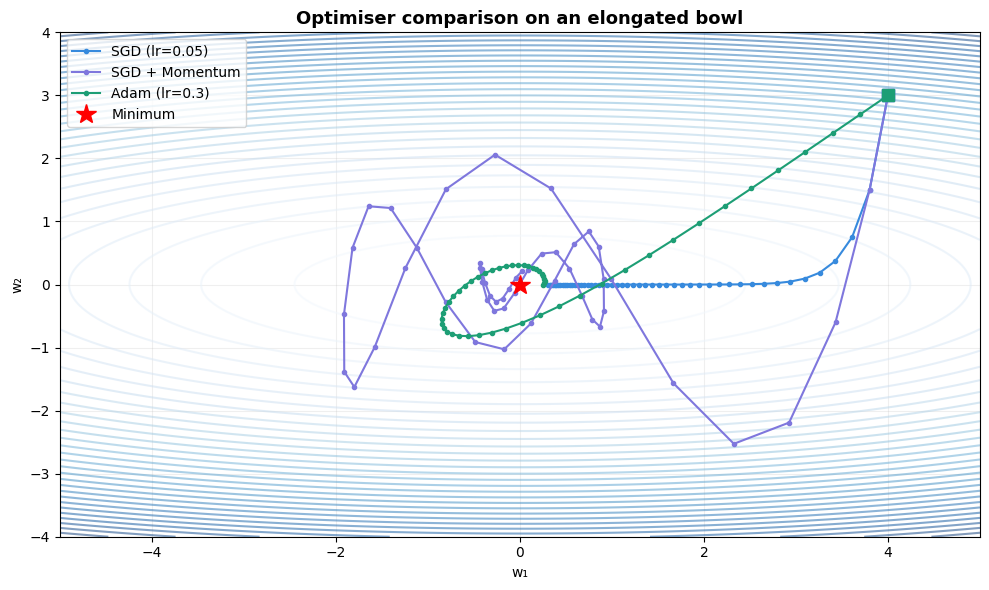

SGD (lr=0.05)             → final loss: 0.047364
SGD + Momentum            → final loss: 0.224632
Adam (lr=0.3)             → final loss: 0.033904


In [14]:
# Implement and visualise optimisers on a 2D loss surface
def loss_fn(x, y):
    """Elongated bowl — harder for vanilla SGD."""
    return 0.5 * x**2 + 5 * y**2

def grad_fn(x, y):
    return np.array([x, 10 * y])

class SGD:
    def __init__(self, lr): self.lr = lr
    def step(self, params, grads):
        return params - self.lr * grads

class SGDMomentum:
    def __init__(self, lr, beta=0.9):
        self.lr, self.beta, self.v = lr, beta, 0
    def step(self, params, grads):
        self.v = self.beta * self.v + grads
        return params - self.lr * self.v

class Adam:
    def __init__(self, lr, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr, self.b1, self.b2, self.eps = lr, beta1, beta2, eps
        self.m, self.v, self.t = 0, 0, 0
    def step(self, params, grads):
        self.t += 1
        self.m = self.b1 * self.m + (1 - self.b1) * grads
        self.v = self.b2 * self.v + (1 - self.b2) * grads**2
        m_hat = self.m / (1 - self.b1**self.t)
        v_hat = self.v / (1 - self.b2**self.t)
        return params - self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

# Run all three from the same starting point
start = np.array([4.0, 3.0])
optimisers = [
    ("SGD (lr=0.05)", SGD(0.05), "#378ADD"),
    ("SGD + Momentum", SGDMomentum(0.05, 0.9), "#7F77DD"),
    ("Adam (lr=0.3)", Adam(0.3), "#1D9E75"),
]

paths = {}
for name, opt, _ in optimisers:
    p = start.copy()
    path = [p.copy()]
    for _ in range(50):
        g = grad_fn(p[0], p[1])
        p = opt.step(p, g)
        path.append(p.copy())
    paths[name] = np.array(path)

# Plot contour + paths
fig, ax = plt.subplots(figsize=(10, 6))
xx, yy = np.meshgrid(np.linspace(-5, 5, 200), np.linspace(-4, 4, 200))
zz = loss_fn(xx, yy)
ax.contour(xx, yy, zz, levels=30, cmap='Blues', alpha=0.5)

for (name, _, color), path in zip(optimisers, paths.values()):
    ax.plot(path[:, 0], path[:, 1], 'o-', color=color, markersize=3,
            linewidth=1.5, label=name)
    ax.plot(path[0, 0], path[0, 1], 's', color=color, markersize=8)  # start

ax.plot(0, 0, '*', color='red', markersize=15, zorder=5, label='Minimum')
ax.set_title('Optimiser comparison on an elongated bowl', fontweight='bold', fontsize=13)
ax.set_xlabel('w₁'); ax.set_ylabel('w₂')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

for name, path in zip([n for n,_,_ in optimisers], paths.values()):
    final_loss = loss_fn(path[-1, 0], path[-1, 1])
    print(f"{name:25s} → final loss: {final_loss:.6f}")

---
# Chapter 6 — Regularisation

## 6.1 Overfitting: the core problem

A model **overfits** when it memorises the training data instead of learning general patterns.  
Signs: training loss keeps decreasing, but validation loss starts increasing.

## 6.2 Techniques

| Technique | What it does | When to use |
|-----------|-------------|------------|
| **L2 regularisation** | Penalises large weights: $\mathcal{L} + \lambda \sum w_i^2$ | Always (default in most frameworks) |
| **Dropout** | Randomly zeroes out neurons during training | Hidden layers in large networks |
| **Early stopping** | Stop training when val loss starts rising | Always — cheapest form of regularisation |
| **Batch normalisation** | Normalises layer outputs per mini-batch | Almost always — also speeds up training |
| **Data augmentation** | Create modified copies of training data | Especially for small datasets |

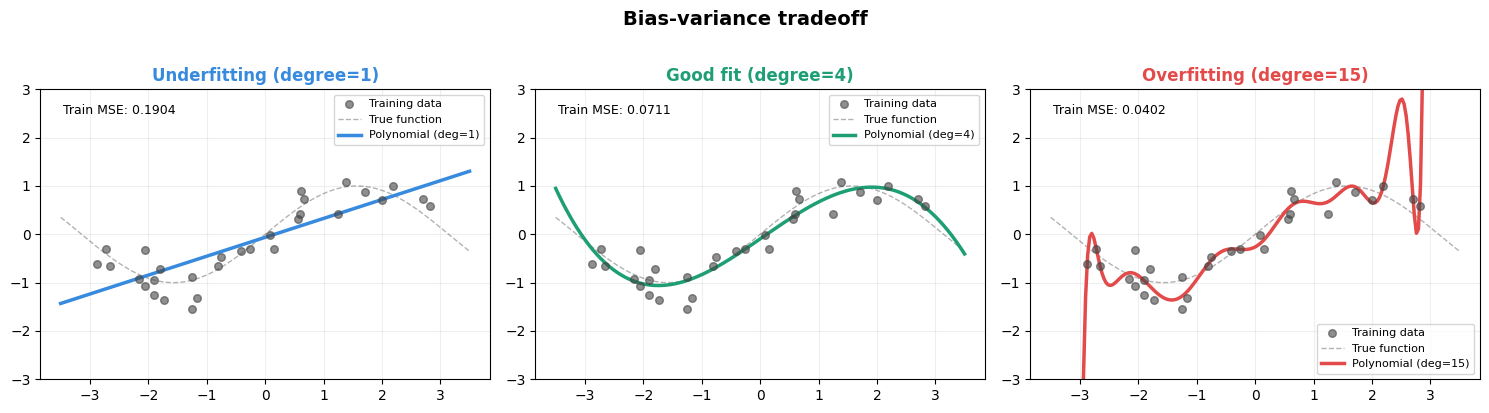

Degree 15 has LOWER training error but would perform terribly on new data.
This is overfitting — the model learned the noise, not the pattern.


In [15]:
# Demonstrate overfitting vs regularisation on a toy problem
np.random.seed(42)

# Generate a simple curved dataset
n = 30
X_train = np.sort(np.random.uniform(-3, 3, n))
y_train = np.sin(X_train) + np.random.randn(n) * 0.3

X_test = np.linspace(-3.5, 3.5, 200)
y_test_true = np.sin(X_test)

# Fit polynomials of different degrees
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

degrees = [1, 4, 15]
titles = ['Underfitting (degree=1)', 'Good fit (degree=4)', 'Overfitting (degree=15)']
colors = ['#378ADD', '#1D9E75', '#E24B4A']

for ax, deg, title, color in zip(axes, degrees, titles, colors):
    # Fit polynomial
    coeffs = np.polyfit(X_train, y_train, deg)
    y_fit = np.polyval(coeffs, X_test)

    # Plot
    ax.scatter(X_train, y_train, s=30, color='#444', alpha=0.6, label='Training data', zorder=3)
    ax.plot(X_test, y_test_true, 'k--', linewidth=1, alpha=0.3, label='True function')
    ax.plot(X_test, y_fit, color=color, linewidth=2.5, label=f'Polynomial (deg={deg})')
    ax.set_title(title, fontweight='bold', color=color)
    ax.set_ylim(-3, 3)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

    # Train MSE
    y_train_pred = np.polyval(coeffs, X_train)
    train_mse = np.mean((y_train - y_train_pred)**2)
    ax.text(0.05, 0.95, f'Train MSE: {train_mse:.4f}', transform=ax.transAxes,
            fontsize=9, verticalalignment='top')

plt.suptitle('Bias-variance tradeoff', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Degree 15 has LOWER training error but would perform terribly on new data.")
print("This is overfitting — the model learned the noise, not the pattern.")

## 6.3 Dropout — implemented from scratch

During training, randomly set each neuron's output to 0 with probability $p$.  
During inference, use all neurons but scale by $(1-p)$.

**Why it works:** Forces the network to not rely on any single neuron — builds redundancy.

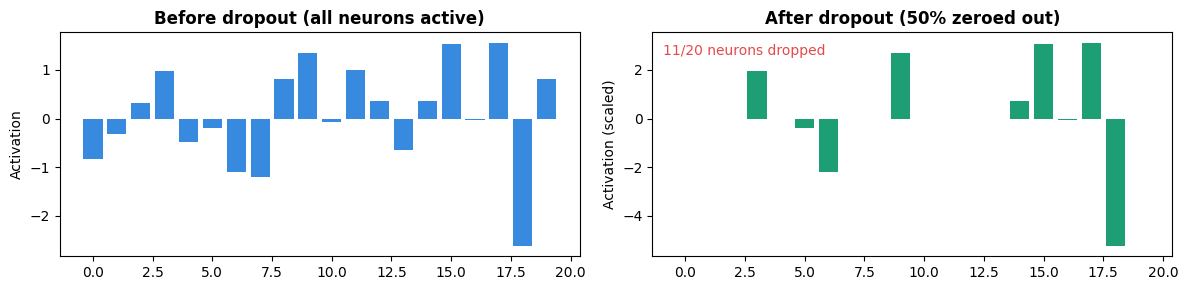

Key: surviving neurons are SCALED UP by 1/(1-p) to keep the expected value the same.
This is called 'inverted dropout' — the approach used by PyTorch.


In [16]:
def dropout_forward(a, drop_rate=0.5, training=True):
    """Apply dropout to activations."""
    if not training or drop_rate == 0:
        return a
    # Create binary mask (inverted dropout — scale at train time)
    mask = (np.random.rand(*a.shape) > drop_rate) / (1 - drop_rate)
    return a * mask

# Visualise dropout
a = np.random.randn(1, 20)  # 20 neurons
a_dropped = dropout_forward(a.copy(), drop_rate=0.5)

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].bar(range(20), a[0], color='#378ADD')
axes[0].set_title('Before dropout (all neurons active)', fontweight='bold')
axes[0].set_ylabel('Activation')

colors = ['#1D9E75' if v != 0 else '#E24B4A' for v in a_dropped[0]]
axes[1].bar(range(20), a_dropped[0], color=colors)
axes[1].set_title('After dropout (50% zeroed out)', fontweight='bold')
axes[1].set_ylabel('Activation (scaled)')

n_dropped = np.sum(a_dropped[0] == 0)
axes[1].text(0.02, 0.95, f'{n_dropped}/20 neurons dropped',
             transform=axes[1].transAxes, fontsize=10, color='#E24B4A', verticalalignment='top')

plt.tight_layout()
plt.show()

print("Key: surviving neurons are SCALED UP by 1/(1-p) to keep the expected value the same.")
print("This is called 'inverted dropout' — the approach used by PyTorch.")

## 6.4 Batch Normalisation

Normalise each layer's input across the mini-batch:

$$\hat{x} = \frac{x - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$$
$$y = \gamma \hat{x} + \beta$$

where $\mu_B$ and $\sigma_B^2$ are the batch mean and variance, and $\gamma$, $\beta$ are learned.

**Why it works:**
1. Keeps activations in a good range (no exploding/vanishing)
2. Acts as a mild regulariser (noise from batch statistics)
3. Allows higher learning rates → faster training

/tmp/ipykernel_7533/835278725.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([batch[:, i] for i in range(8)], labels=[f'f{i}' for i in range(8)])
/tmp/ipykernel_7533/835278725.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([normed[:, i] for i in range(8)], labels=[f'f{i}' for i in range(8)])


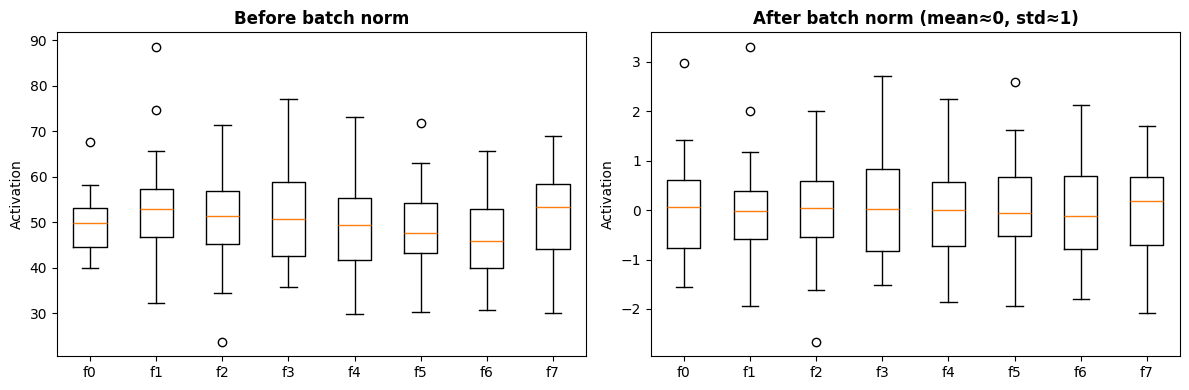

Before: mean=50.0, std=9.5
After:  mean=-0.0000, std=1.0000


In [17]:
def batch_norm_1d(x, gamma, beta, eps=1e-5):
    """Batch normalisation for a fully-connected layer.
    x shape: (batch_size, features)
    gamma, beta shape: (features,)
    """
    mu = x.mean(axis=0)                    # per-feature mean
    var = x.var(axis=0)                    # per-feature variance
    x_hat = (x - mu) / np.sqrt(var + eps)  # normalise
    return gamma * x_hat + beta            # scale and shift

# Demo: batch norm tames wild activations
np.random.seed(42)
batch = np.random.randn(32, 8) * 10 + 50  # wild: mean≈50, std≈10
gamma = np.ones(8)
beta = np.zeros(8)
normed = batch_norm_1d(batch, gamma, beta)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot([batch[:, i] for i in range(8)], labels=[f'f{i}' for i in range(8)])
axes[0].set_title('Before batch norm', fontweight='bold')
axes[0].set_ylabel('Activation')

axes[1].boxplot([normed[:, i] for i in range(8)], labels=[f'f{i}' for i in range(8)])
axes[1].set_title('After batch norm (mean≈0, std≈1)', fontweight='bold')
axes[1].set_ylabel('Activation')

plt.tight_layout()
plt.show()

print(f"Before: mean={batch.mean(0).mean():.1f}, std={batch.std(0).mean():.1f}")
print(f"After:  mean={normed.mean(0).mean():.4f}, std={normed.std(0).mean():.4f}")

---
# Chapter 7 — Weight Initialisation

Bad initialisation can make or break training. If weights start too large → activations explode. Too small → gradients vanish.

| Method | Formula | Best for |
|--------|---------|----------|
| **Xavier/Glorot** | $W \sim \mathcal{N}(0, \frac{2}{n_{in} + n_{out}})$ | Sigmoid, Tanh |
| **He/Kaiming** | $W \sim \mathcal{N}(0, \frac{2}{n_{in}})$ | ReLU (the standard) |
| **Zeros** | All zeros | NEVER (all neurons compute the same thing) |

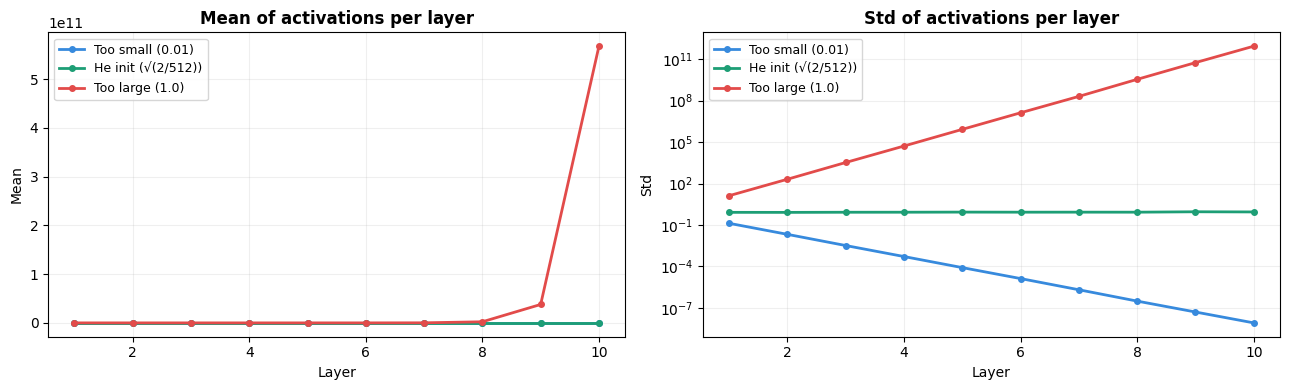

Too small → activations collapse to zero (vanishing signals)
Too large → activations explode to infinity
He init  → activations stay stable across ALL layers ✓


In [18]:
# Demonstrate: propagate random data through 10 layers with different init
def propagate(n_layers, init_scale, activation='relu'):
    """Track activation statistics through layers."""
    x = np.random.randn(256, 512)  # batch of 256, 512 features
    means, stds = [], []

    for _ in range(n_layers):
        W = np.random.randn(512, 512) * init_scale
        x = x @ W
        if activation == 'relu':
            x = np.maximum(0, x)
        means.append(x.mean())
        stds.append(x.std())

    return means, stds

configs = [
    ("Too small (0.01)", 0.01, "#378ADD"),
    ("He init (√(2/512))", np.sqrt(2/512), "#1D9E75"),
    ("Too large (1.0)", 1.0, "#E24B4A"),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, scale, color in configs:
    means, stds = propagate(10, scale)
    axes[0].plot(range(1, 11), means, 'o-', color=color, label=name, linewidth=2, markersize=4)
    axes[1].plot(range(1, 11), stds, 'o-', color=color, label=name, linewidth=2, markersize=4)

axes[0].set_title('Mean of activations per layer', fontweight='bold')
axes[0].set_xlabel('Layer'); axes[0].set_ylabel('Mean')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.2)

axes[1].set_title('Std of activations per layer', fontweight='bold')
axes[1].set_xlabel('Layer'); axes[1].set_ylabel('Std')
axes[1].set_yscale('log')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print("Too small → activations collapse to zero (vanishing signals)")
print("Too large → activations explode to infinity")
print("He init  → activations stay stable across ALL layers ✓")

---
# Summary — What you've learned

| Concept | Key equation | Intuition |
|---------|-------------|----------|
| Neuron | $a = \sigma(\mathbf{w}^T\mathbf{x} + b)$ | Linear classifier + non-linearity |
| Activation | ReLU = $\max(0, z)$ | Enables learning complex patterns |
| Network | Stack layers: $a^{(l)} = \sigma(W^{(l)} a^{(l-1)} + b^{(l)})$ | Depth = representational power |
| Softmax | $p_i = e^{z_i} / \sum e^{z_j}$ | Logits → probabilities |
| MSE loss | $\frac{1}{N}\sum(y - \hat{y})^2$ | For regression |
| CE loss | $-\frac{1}{N}\sum\log p_{y_i}$ | For classification |
| Backprop | Chain rule through layers | Compute all gradients efficiently |
| SGD | $w ← w - \eta \nabla L$ | Simplest optimiser |
| Adam | Momentum + adaptive lr | Default choice |
| Dropout | Random zero-out (p=0.5) | Prevents over-reliance on any neuron |
| Batch norm | Normalise per mini-batch | Stable training, higher lr |
| He init | $W \sim \mathcal{N}(0, 2/n_{in})$ | Proper initialisation for ReLU |

**Next:** We'll implement all of this in PyTorch (the PyTorch Deep Dive notebook), then train a real network on MNIST (the MNIST notebook).